# CreditRisk+ em 24 safras de crédito PF no Brasil

Este estudo simula uma carteira bancária **sintética** com cartão de crédito e crédito pessoal parcelado. São geradas 36 safras mensais; as 12 primeiras formam o *ramp-up* e as 24 seguintes compõem o período reportado. O CreditRisk+ é aplicado (i) a cada safra na originação e (ii) a cada fechamento mensal da carteira ativa.

Objetivos: acompanhar exposição, perda esperada (EL), volatilidade, VaR 95%/99%/99,9%, capital econômico, composição por produto, defaults realizados e curvas de vintage por MOB (*months on book*). Toda aleatoriedade usa semente fixa; já o CreditRisk+ é analítico e determinístico.

## Fontes, escopo e interpretação

O cenário usa apenas âncoras de plausibilidade, não pretende reproduzir uma instituição específica. O Banco Central define inadimplência dessas modalidades como saldo com parcela em atraso superior a 90 dias nas séries de [cartão de crédito total (SGS 21129)](https://dadosabertos.bcb.gov.br/dataset/21129-inadimplencia-da-carteira-de-credito-com-recursos-livres---pessoas-fisicas---cartao-de-credit) e [crédito pessoal não consignado (SGS 21114)](https://dadosabertos.bcb.gov.br/dataset/21114-inadimplencia-da-carteira-de-credito-com-recursos-livres---pessoas-fisicas---credito-pessoal-). O [Relatório de Economia Bancária 2023](https://www.bcb.gov.br/content/publicacoes/relatorioeconomiabancaria/reb2023p.pdf) documenta a sensibilidade do crédito livre PF a juros, endividamento, concessões e baixas para prejuízo.

As PDs, LGDs, volumes e o choque abaixo são **hipóteses explícitas do cenário**. Eles não são estimativas extraídas diretamente dessas séries e não devem ser usados para decisão real sem calibração, validação temporal e governança. O horizonte da PD e da distribuição CreditRisk+ é de 12 meses; defaults realizados mensais usam a taxa marginal equivalente.

In [1]:
# Imports e configuração reprodutível.
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from creditriskplus.retail import (
    RetailSimulationConfig,
    SECTOR_COLUMNS,
    simulate_retail_portfolio,
    run_creditriskplus_over_time,
    run_creditriskplus_by_cohort,
    vintage_default_curves,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

config = RetailSimulationConfig(
    n_months=36,
    warmup_months=12,
    seed=20260808,
    unit_size=250.0,
)
config

RetailSimulationConfig(start='2022-01-01', n_months=36, warmup_months=12, seed=20260808, average_monthly_card_originations=150, average_monthly_installment_originations=110, unit_size=250.0, tail_tolerance=1e-08)

## Construção metodológica

Cada linha representa um pool homogêneo por safra, produto e faixa de risco. `obligor_count` é a multiplicidade: no CreditRisk+, multiplicar as contribuições de $\varepsilon_A$, $\mu_k$ e $\sigma_k$ pelo número de contratos é exatamente equivalente a repetir os contratos individuais.

- **Cartão:** EAD cresce nos primeiros meses com ativação/utilização e aumenta moderadamente sob estresse; não há amortização contratual.
- **Parcelado:** saldo inicial maior e amortização até 24–30 meses; saídas antecipadas e defaults reduzem contratos ativos.
- **Risco:** quatro faixas A–D, seasoning por MOB, PD de 12 meses e choque macro transitório; a oferta se contrai e o underwriting fica mais seletivo durante o choque.
- **Setores:** 15% específico (variância zero, A12.3), 45% macro e 40% do produto. Os pesos somam 100% por pool.
- **LGD:** 85% no cartão e 78% no parcelado; recuperações entram reduzindo a exposição antes do banding.

A unidade de R$ 250 mantém até 100 bandas para as maiores exposições individuais. A EL original é preservada exatamente pelo ajuste de PD das equações 11–13; o efeito residual do banding recai sobretudo sobre a variância.

In [2]:
# Simula sequencialmente originações, defaults, saídas e saldos.
panel = simulate_retail_portfolio(config)

assert panel['cohort_month'].nunique() == 36
assert panel['observation_month'].nunique() == 36
assert np.allclose(panel[list(SECTOR_COLUMNS)].sum(axis=1), 1.0)
assert (panel['obligor_count'] >= 0).all()

print(f'Linhas pool-mês: {len(panel):,}')
print(f'Safras simuladas: {panel.cohort_month.nunique()} (12 ramp-up + 24 reportadas)')
print(f'Período: {panel.observation_month.min():%m/%Y} a {panel.observation_month.max():%m/%Y}')
display(panel.head(8))

Linhas pool-mês: 5,163
Safras simuladas: 36 (12 ramp-up + 24 reportadas)
Período: 01/2022 a 12/2024


,observation_month,cohort_month,mob,product,risk_band,originated_count,obligor_count,ead_per_obligor,pd_12m,std_pd_12m,recovery_rate,realized_defaults,realized_exits,macro_multiplier,sector_weight_specific,sector_weight_macro,sector_weight_card,sector_weight_installment
0,2022-01-01,2022-01-01,0,Cartão de crédito,A,44,44,"1,728.0000",0.0078,0.0051,0.1500,0,0,1.0000,0.1500,0.4500,0.4000,0.0000
1,2022-01-01,2022-01-01,0,Cartão de crédito,B,49,49,"2,376.0000",0.0228,0.0148,0.1500,0,0,1.0000,0.1500,0.4500,0.4000,0.0000
2,2022-01-01,2022-01-01,0,Cartão de crédito,C,33,33,"3,096.0000",0.0520,0.0338,0.1500,0,2,1.0000,0.1500,0.4500,0.4000,0.0000
3,2022-01-01,2022-01-01,0,Cartão de crédito,D,14,14,"3,744.0000",0.1170,0.0760,0.1500,1,0,1.0000,0.1500,0.4500,0.4000,0.0000
4,2022-01-01,2022-01-01,0,Crédito pessoal parcelado,A,40,40,"7,500.0000",0.0099,0.0054,0.2200,0,0,1.0000,0.1500,0.4500,0.0000,0.4000
5,2022-01-01,2022-01-01,0,Crédito pessoal parcelado,B,31,31,"9,000.0000",0.0248,0.0136,0.2200,0,0,1.0000,0.1500,0.4500,0.0000,0.4000
6,2022-01-01,2022-01-01,0,Crédito pessoal parcelado,C,26,26,"10,500.0000",0.0550,0.0303,0.2200,0,3,1.0000,0.1500,0.4500,0.0000,0.4000
7,2022-01-01,2022-01-01,0,Crédito pessoal parcelado,D,12,12,"12,000.0000",0.1210,0.0666,0.2200,0,0,1.0000,0.1500,0.4500,0.0000,0.4000


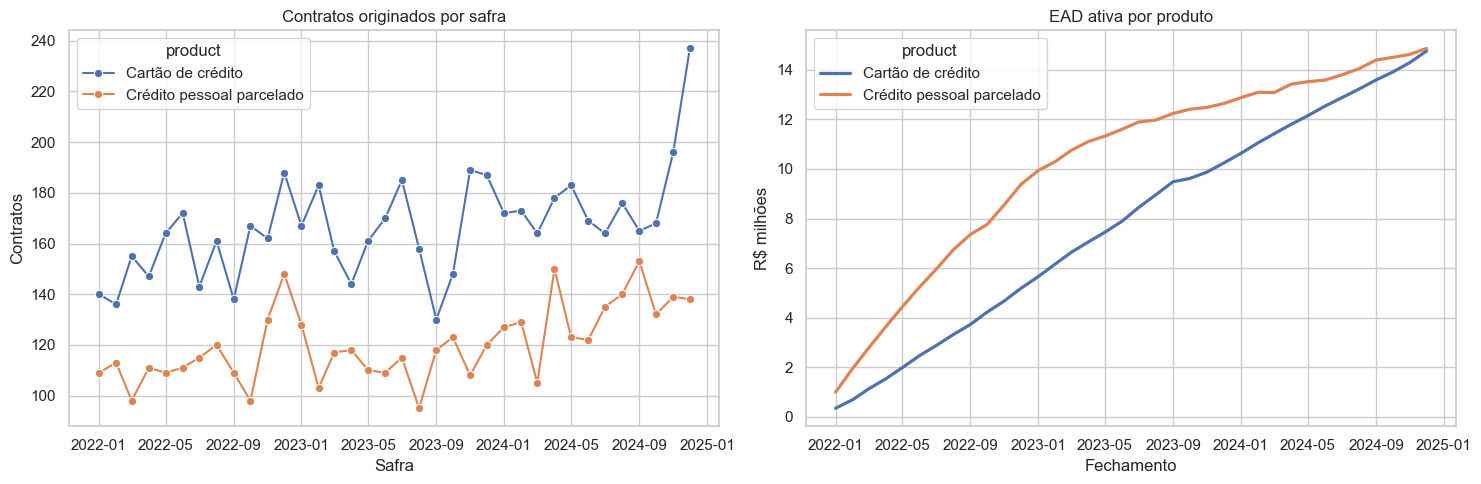

In [3]:
# Visão da originação e do crescimento da carteira antes do cálculo de risco.
origin = (panel[panel['mob'] == 0]
          .groupby(['cohort_month', 'product'], as_index=False)
          .agg(contracts=('obligor_count', 'sum')))
panel_plot = panel.assign(pool_ead=panel.obligor_count * panel.ead_per_obligor)
ead_product = (panel_plot.groupby(['observation_month', 'product'], as_index=False)
               .agg(gross_ead=('pool_ead', 'sum')))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=origin, x='cohort_month', y='contracts', hue='product', marker='o', ax=axes[0])
axes[0].set(title='Contratos originados por safra', xlabel='Safra', ylabel='Contratos')
sns.lineplot(data=ead_product, x='observation_month', y=ead_product.gross_ead/1e6,
             hue='product', linewidth=2.3, ax=axes[1])
axes[1].set(title='EAD ativa por produto', xlabel='Fechamento', ylabel='R$ milhões')
plt.tight_layout(); plt.show()

## Aplicação do CreditRisk+

Para cada fechamento e safra, calcula-se a PGF setorial Poisson–Gama e sua PMF pela recursão A10. O domínio começa em $EL+10\sigma$ e é ampliado até a massa omitida ficar abaixo de $10^{-8}$ e comportar o percentil 99,9%. A massa truncada **não é renormalizada**. VaR é o quantil discreto $\min\{nL:F(nL)\ge q\}$; a interpolação do XLS não é usada nos relatórios econômicos.

In [4]:
# 24 fechamentos após ramp-up e 24 safras em sua fotografia de originação.
monthly_metrics = run_creditriskplus_over_time(panel, config)
cohort_metrics = run_creditriskplus_by_cohort(panel, config)
vintage_curves = vintage_default_curves(panel, config)

assert len(monthly_metrics) == 24
assert len(cohort_metrics) == 24
assert monthly_metrics.tail_mass.max() <= config.tail_tolerance
assert cohort_metrics.tail_mass.max() <= config.tail_tolerance
assert (monthly_metrics.var_999 >= monthly_metrics.var_99).all()
assert (monthly_metrics.var_99 >= monthly_metrics.expected_loss).all()

print('Validações concluídas: 24 safras, 24 fechamentos e caudas numericamente controladas.')

Validações concluídas: 24 safras, 24 fechamentos e caudas numericamente controladas.


In [5]:
# Tabela executiva mensal em R$ milhões.
executive = monthly_metrics.copy()
for column in ['gross_ead', 'expected_loss', 'loss_std', 'var_95', 'var_99',
               'var_999', 'economic_capital_99', 'economic_capital_999']:
    executive[column] /= 1e6
executive = executive.rename(columns={
    'observation_month': 'Fechamento', 'active_obligors': 'Clientes ativos',
    'gross_ead': 'EAD (R$ mi)', 'expected_loss': 'EL (R$ mi)',
    'loss_std': 'Sigma (R$ mi)', 'var_95': 'VaR95 (R$ mi)',
    'var_99': 'VaR99 (R$ mi)', 'var_999': 'VaR99,9 (R$ mi)',
    'economic_capital_99': 'EC99 (R$ mi)',
    'economic_capital_999': 'EC99,9 (R$ mi)', 'tail_mass': 'Massa truncada'
})
executive_view = executive[['Fechamento', 'Clientes ativos', 'EAD (R$ mi)', 'EL (R$ mi)',
                             'VaR99 (R$ mi)', 'VaR99,9 (R$ mi)', 'EC99 (R$ mi)',
                             'Massa truncada']].copy()
numeric_columns = executive_view.columns.difference(['Fechamento'])
executive_view[numeric_columns] = executive_view[numeric_columns].round(4)
display(executive_view)

,Fechamento,Clientes ativos,EAD (R$ mi),EL (R$ mi),VaR99 (R$ mi),"VaR99,9 (R$ mi)",EC99 (R$ mi),Massa truncada
0,2023-01-01,3239,15.5855,0.8192,1.6095,1.9965,0.7903,0.0000
1,2023-02-01,3481,16.4662,0.8973,1.7600,2.1832,0.8627,0.0000
2,2023-03-01,3702,17.3670,0.9795,1.9188,2.3795,0.9393,0.0000
3,2023-04-01,3910,18.1476,1.0325,2.0210,2.5065,0.9885,0.0000
4,2023-05-01,4105,18.7589,1.0659,2.0855,2.5862,1.0196,0.0000
5,2023-06-01,4323,19.4839,1.0974,2.1463,2.6615,1.0489,0.0000
6,2023-07-01,4560,20.3305,1.2893,2.5180,3.1220,1.2287,0.0000
7,2023-08-01,4734,20.9271,1.5279,2.9800,3.6945,1.4521,0.0000
8,2023-09-01,4905,21.7169,1.8882,3.6782,4.5592,1.7901,0.0000
9,2023-10-01,5076,22.0180,1.6483,3.2130,3.9828,1.5647,0.0000


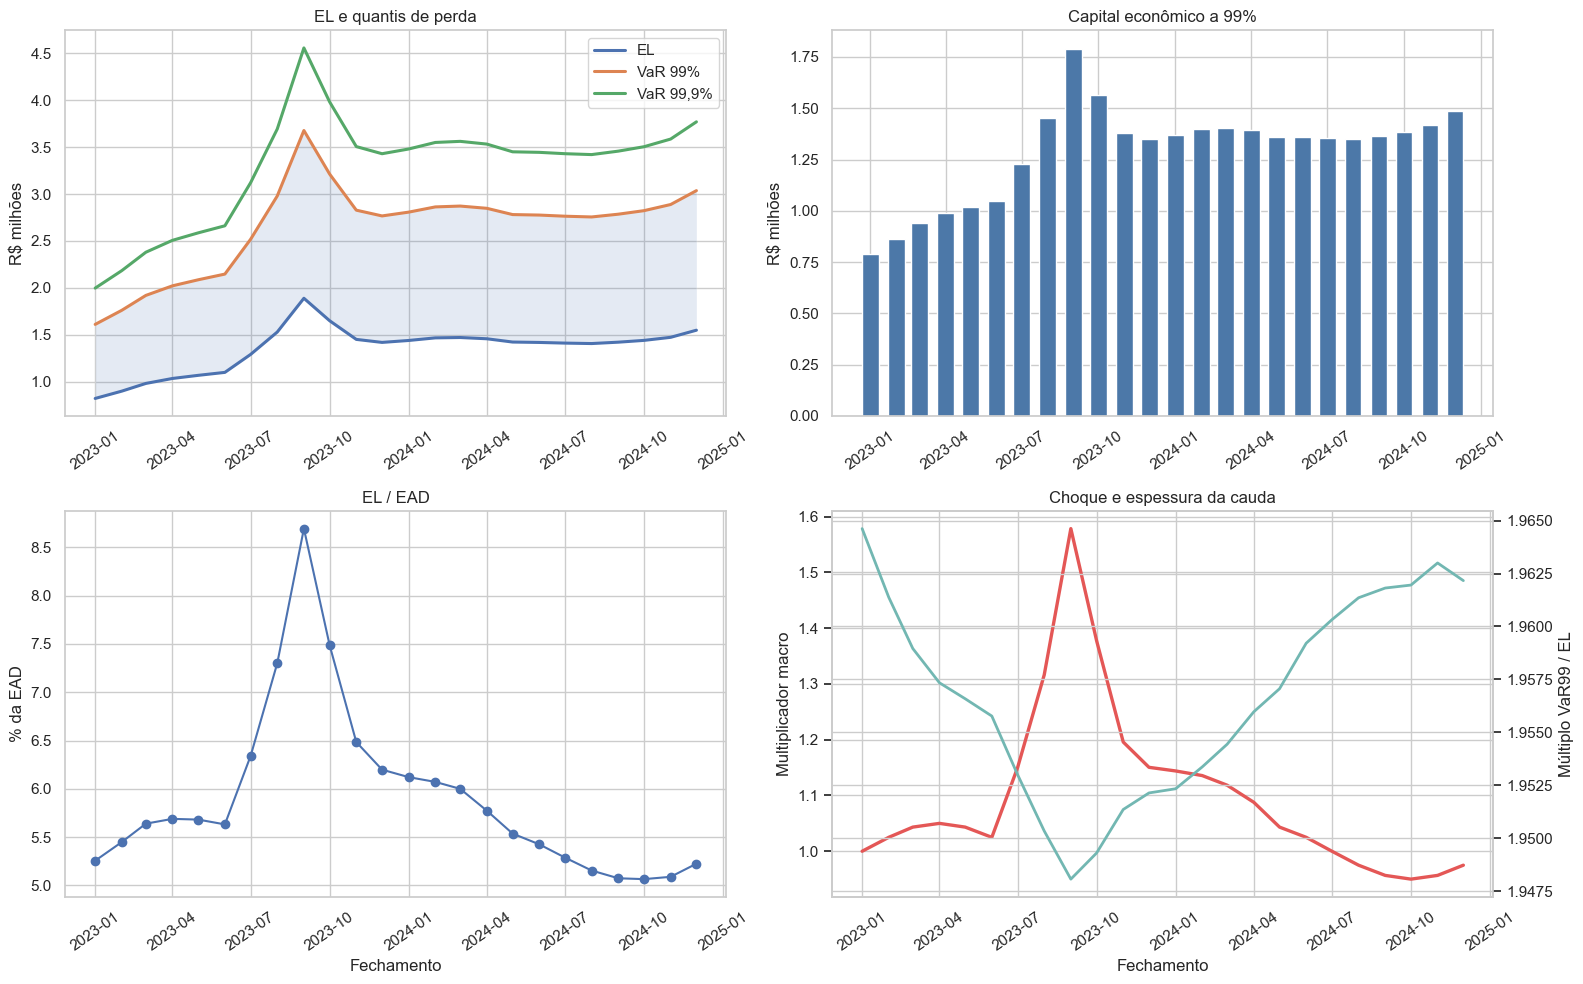

In [6]:
# Evolução temporal dos principais indicadores de risco.
m = monthly_metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].plot(m.observation_month, m.expected_loss/1e6, label='EL', lw=2.2)
axes[0, 0].plot(m.observation_month, m.var_99/1e6, label='VaR 99%', lw=2.2)
axes[0, 0].plot(m.observation_month, m.var_999/1e6, label='VaR 99,9%', lw=2.2)
axes[0, 0].fill_between(m.observation_month, m.expected_loss/1e6, m.var_99/1e6, alpha=.15)
axes[0, 0].set(title='EL e quantis de perda', ylabel='R$ milhões'); axes[0, 0].legend()

axes[0, 1].bar(m.observation_month, m.economic_capital_99/1e6, width=20, color='#4c78a8')
axes[0, 1].set(title='Capital econômico a 99%', ylabel='R$ milhões')

axes[1, 0].plot(m.observation_month, 100*m.expected_loss/m.gross_ead, marker='o')
axes[1, 0].set(title='EL / EAD', ylabel='% da EAD', xlabel='Fechamento')

axes[1, 1].plot(m.observation_month, m.macro_multiplier, color='#e45756', lw=2.4, label='Fator macro')
ax2 = axes[1, 1].twinx()
ax2.plot(m.observation_month, m.var_99/m.expected_loss, color='#72b7b2', lw=2, label='VaR99 / EL')
axes[1, 1].set(title='Choque e espessura da cauda', ylabel='Multiplicador macro', xlabel='Fechamento')
ax2.set_ylabel('Múltiplo VaR99 / EL')
for ax in axes.flat: ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()

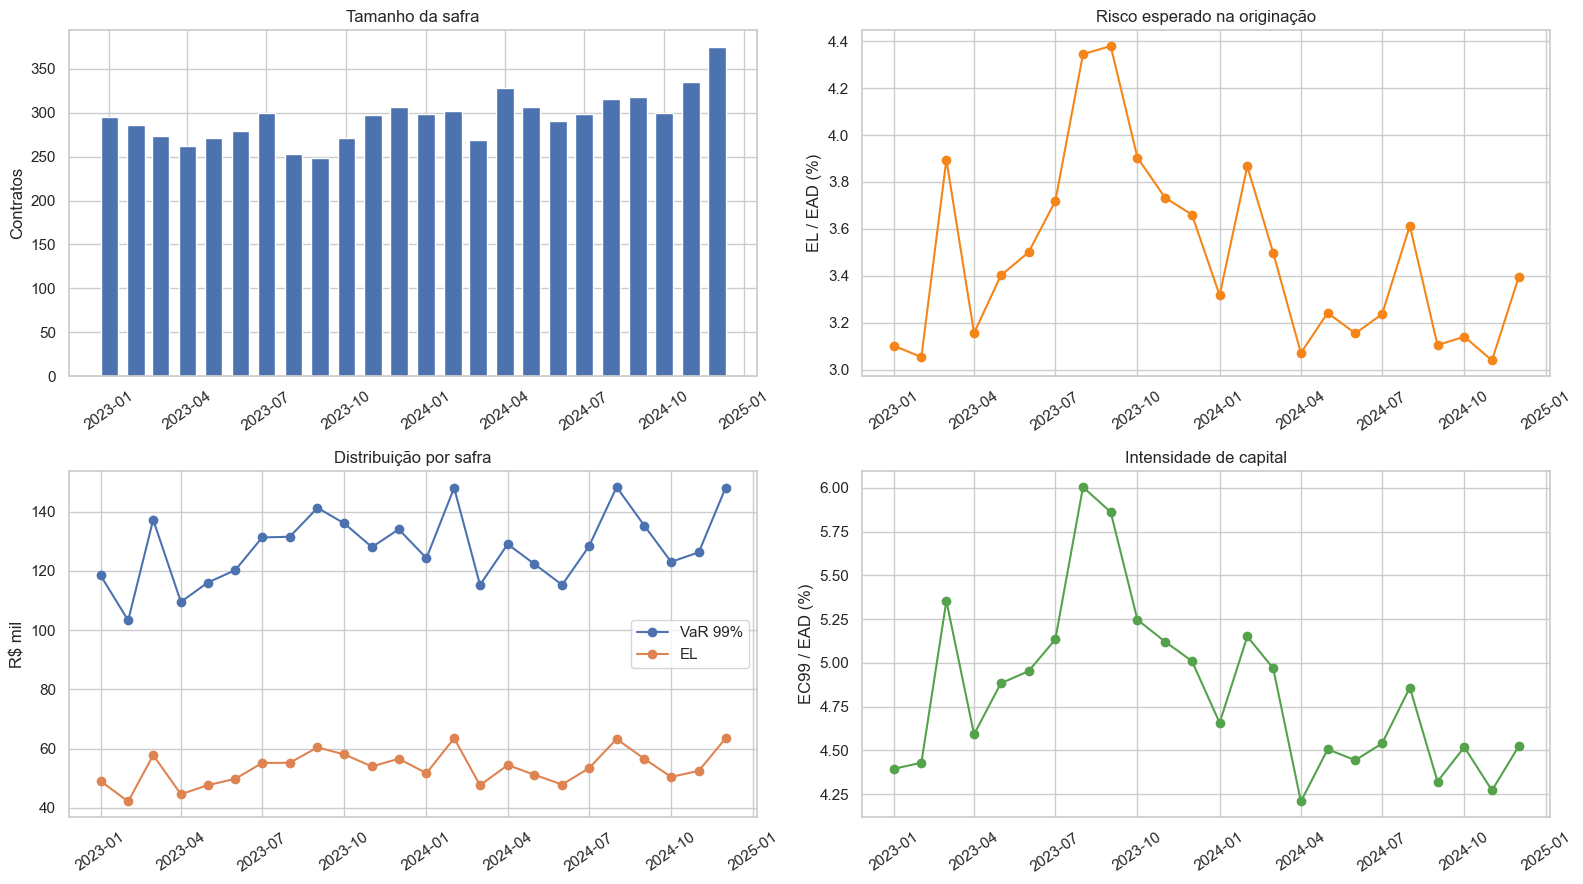

In [7]:
# CreditRisk+ aplicado isoladamente a cada uma das 24 safras reportadas.
c = cohort_metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes[0, 0].bar(c.cohort_month, c.originated_obligors, width=20)
axes[0, 0].set(title='Tamanho da safra', ylabel='Contratos')
axes[0, 1].plot(c.cohort_month, 100*c.expected_loss/c.origination_ead, marker='o', color='#f58518')
axes[0, 1].set(title='Risco esperado na originação', ylabel='EL / EAD (%)')
axes[1, 0].plot(c.cohort_month, c.var_99/1e3, marker='o', label='VaR 99%')
axes[1, 0].plot(c.cohort_month, c.expected_loss/1e3, marker='o', label='EL')
axes[1, 0].set(title='Distribuição por safra', ylabel='R$ mil'); axes[1, 0].legend()
axes[1, 1].plot(c.cohort_month, c.economic_capital_99/c.origination_ead*100, marker='o', color='#54a24b')
axes[1, 1].set(title='Intensidade de capital', ylabel='EC99 / EAD (%)')
for ax in axes.flat: ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()

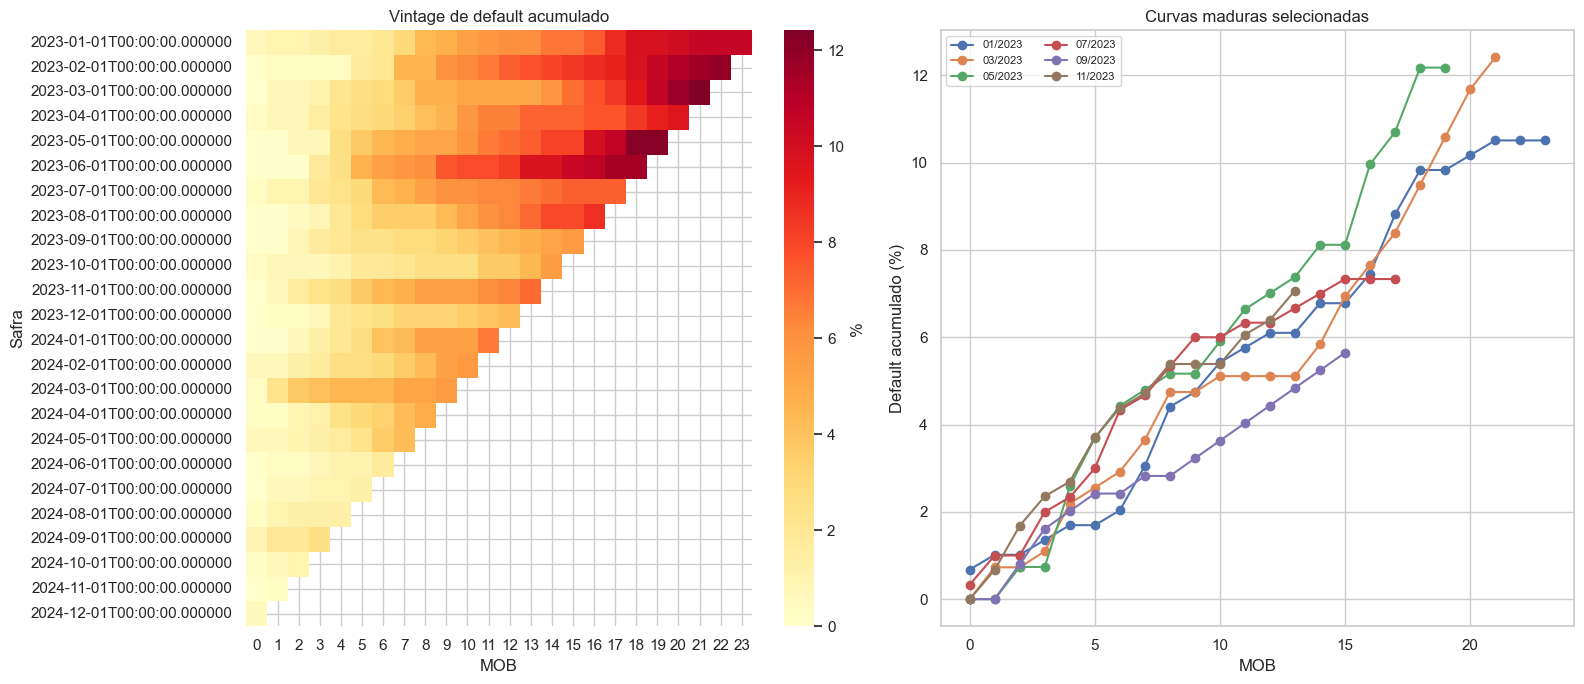

In [8]:
# Curvas de vintage: taxa de default realizada acumulada por idade da safra.
pivot = vintage_curves.pivot(index='cohort_month', columns='mob', values='cumulative_default_rate')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(pivot*100, cmap='YlOrRd', mask=pivot.isna(), ax=axes[0], cbar_kws={'label': '%'})
axes[0].set(title='Vintage de default acumulado', xlabel='MOB', ylabel='Safra')

for cohort in pivot.index[:12:2]:
    curve = pivot.loc[cohort].dropna()
    axes[1].plot(curve.index, curve.values*100, marker='o', label=f'{cohort:%m/%Y}')
axes[1].set(title='Curvas maduras selecionadas', xlabel='MOB', ylabel='Default acumulado (%)')
axes[1].legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

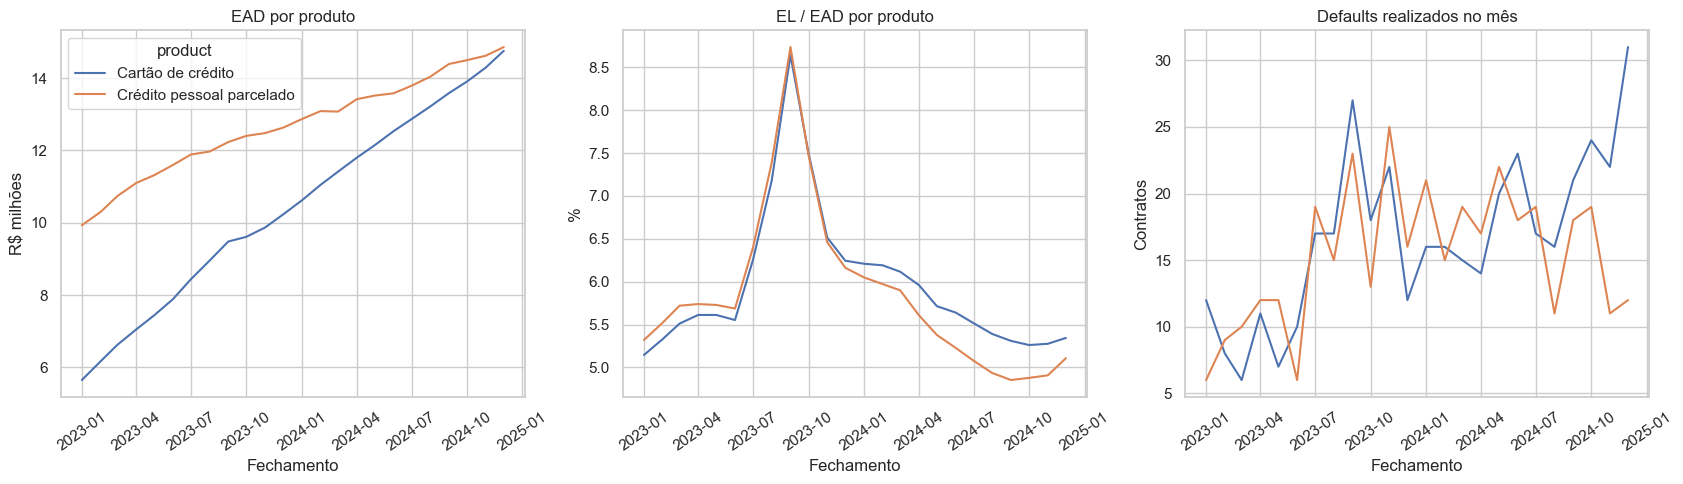

,EAD_medio_R_mi,EL_media_R_mi,taxa_EL_media,defaults
product,,,,
Cartão de crédito,10.4001,0.6164,0.0596,402
Crédito pessoal parcelado,12.6813,0.7366,0.0584,368


In [9]:
# Decomposição contábil de EAD e EL por produto nos 24 fechamentos reportados.
reported = panel[panel.observation_month.isin(monthly_metrics.observation_month)].copy()
reported['gross_ead_pool'] = reported.obligor_count * reported.ead_per_obligor
reported['el_pool'] = (reported.gross_ead_pool * (1-reported.recovery_rate) * reported.pd_12m)
product_time = (reported.groupby(['observation_month', 'product'], as_index=False)
                .agg(gross_ead=('gross_ead_pool', 'sum'), expected_loss=('el_pool', 'sum'),
                     defaults=('realized_defaults', 'sum')))
product_time['el_rate'] = product_time.expected_loss/product_time.gross_ead

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.lineplot(data=product_time, x='observation_month', y=product_time.gross_ead/1e6,
             hue='product', ax=axes[0])
axes[0].set(title='EAD por produto', ylabel='R$ milhões', xlabel='Fechamento')
sns.lineplot(data=product_time, x='observation_month', y=product_time.el_rate*100,
             hue='product', ax=axes[1], legend=False)
axes[1].set(title='EL / EAD por produto', ylabel='%', xlabel='Fechamento')
sns.lineplot(data=product_time, x='observation_month', y='defaults', hue='product',
             ax=axes[2], legend=False)
axes[2].set(title='Defaults realizados no mês', ylabel='Contratos', xlabel='Fechamento')
for ax in axes: ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()

display(product_time.groupby('product').agg(
    EAD_medio=('gross_ead', 'mean'), EL_media=('expected_loss', 'mean'),
    taxa_EL_media=('el_rate', 'mean'), defaults=('defaults', 'sum')
).assign(EAD_medio_R_mi=lambda x: x.EAD_medio/1e6,
         EL_media_R_mi=lambda x: x.EL_media/1e6)
  [['EAD_medio_R_mi', 'EL_media_R_mi', 'taxa_EL_media', 'defaults']].round(4))

In [10]:
# Diagnósticos e leitura automática dos principais movimentos.
peak = monthly_metrics.loc[monthly_metrics.economic_capital_99.idxmax()]
start = monthly_metrics.iloc[0]
end = monthly_metrics.iloc[-1]
worst_cohort = cohort_metrics.loc[(cohort_metrics.expected_loss/cohort_metrics.origination_ead).idxmax()]

diagnostics = pd.Series({
    'Maior massa truncada': monthly_metrics.tail_mass.max(),
    'Menor massa acumulada': 1-monthly_metrics.tail_mass.max(),
    'Crescimento da EAD (24 meses)': end.gross_ead/start.gross_ead-1,
    'Variação da EL': end.expected_loss/start.expected_loss-1,
    'EC99 máximo / EAD': peak.economic_capital_99/peak.gross_ead,
})
display(diagnostics.to_frame('valor'))
print(f'Pico de capital: {peak.observation_month:%m/%Y}, EC99 = R$ {peak.economic_capital_99/1e6:.2f} mi.')
print(f'Safra de maior EL/EAD: {worst_cohort.cohort_month:%m/%Y}, '      f'{100*worst_cohort.expected_loss/worst_cohort.origination_ead:.2f}%.')
print('A massa truncada máxima permanece muito abaixo da tolerância; os quantis não dependem de renormalização.')

,valor
Maior massa truncada,0.0000
Menor massa acumulada,1.0000
Crescimento da EAD (24 meses),0.9003
Variação da EL,0.8890
EC99 máximo / EAD,0.0824


Pico de capital: 09/2023, EC99 = R$ 1.79 mi.
Safra de maior EL/EAD: 09/2023, 4.38%.
A massa truncada máxima permanece muito abaixo da tolerância; os quantis não dependem de renormalização.


## Conclusões e limitações

A leitura conjunta separa três efeitos: crescimento do saldo, mudança do mix de risco e dependência sistemática. Durante o choque, a originação recua e melhora marginalmente de mix, mas as exposições já ativas sofrem aumento de PD e utilização; por isso EL e capital do estoque podem piorar mesmo com underwriting mais conservador nas novas safras. O parcelado amortiza e limita a persistência de EAD, enquanto o cartão mantém exposição aberta e responde mais rapidamente ao estresse.

Limitações materiais: (1) CreditRisk+ usa aproximação Poisson para defaults raros e não modela diretamente migração/cura; (2) fatores Gama são independentes entre setores; (3) EAD, PD e recuperação são pontuais dentro de cada pool; (4) o choque é cenário, não previsão; (5) VaR não é medida coerente e deve ser complementado por Expected Shortfall, stress testing, backtesting e limites de concentração; (6) para produção seriam necessários calibração em dados internos, tratamento de censura das safras recentes, validação fora da amostra e governança regulatória.